### Convolutional Neural Networks for Image Classification on MNSIT Dataset

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension (important for CNN)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [18]:
from tensorflow.keras import layers, models

model = models.Sequential()

# ✅ Add Input layer first
model.add(layers.Input(shape=(28, 28, 1)))

# Now add CNN layers
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [19]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9521 - loss: 0.1619 - val_accuracy: 0.9848 - val_loss: 0.0561
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9839 - loss: 0.0513 - val_accuracy: 0.9880 - val_loss: 0.0405
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9889 - loss: 0.0356 - val_accuracy: 0.9897 - val_loss: 0.0388
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9916 - loss: 0.0262 - val_accuracy: 0.9897 - val_loss: 0.0407
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9931 - loss: 0.0200 - val_accuracy: 0.9905 - val_loss: 0.0357


In [21]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9904 - loss: 0.0318
Test Accuracy: 0.9904000163078308


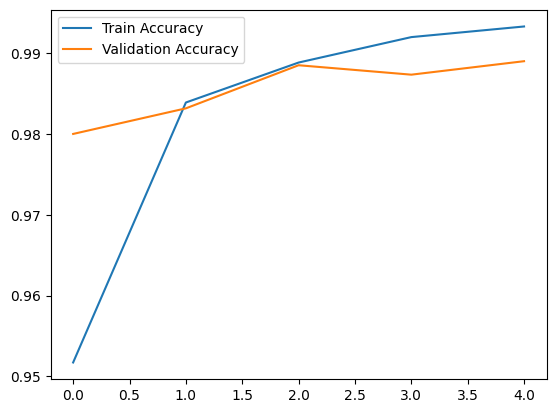

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [13]:
import numpy as np

predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [14]:
predicted_labels = np.argmax(predictions, axis=1)

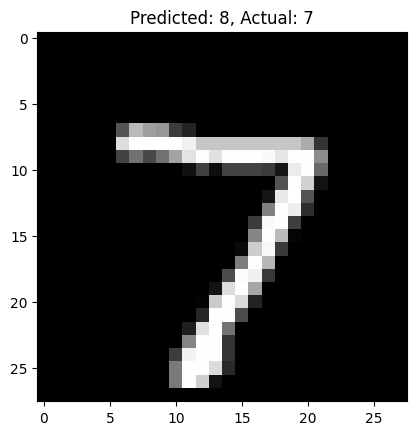

In [15]:
import matplotlib.pyplot as plt

plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_labels[0]}, Actual: {y_test[0]}")
plt.show()

In [16]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, predicted_labels))

Accuracy: 0.0003


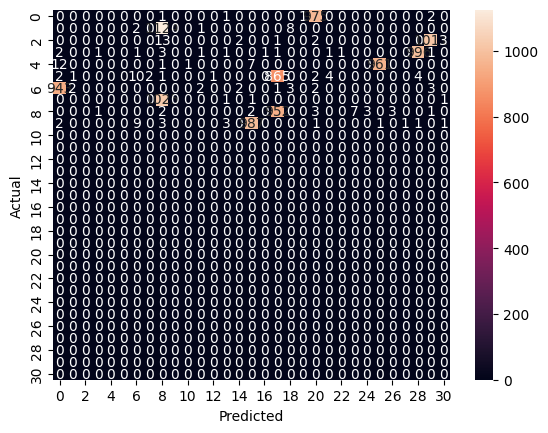

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_labels)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()